In [21]:
# ============================================================
# Transformer 时间序列版本：直接从原始用户 CSV 构造序列
# 不使用 final0.7_augmented.csv
# 输入形状：[样本数, 时间步, 特征数]
# 目标：pam_t+predict_horizon - pam_t
# ============================================================

import os
import sys
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入 02 Stacking 文件夹中的 features.py
sys.path.append(str(Path("../02 Stacking").resolve()))
from features import features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader



In [22]:

# ============================================================
# 1. 路径设置
# ============================================================

sys.path.append(str(Path("../00_common").resolve()))
from base_path import ROOT

path = ROOT / "03 Transformer" / "改进后"
input_folder = ROOT / "01 数据处理" / "07split_by_uid"

path.mkdir(parents=True, exist_ok=True)

print("输入文件夹：", input_folder)
print("输出路径：", path)



输入文件夹： /home/wei/Data/light/01 数据处理/07split_by_uid
输出路径： /home/wei/Data/light/03 Transformer/改进后


In [23]:

# ============================================================
# 2. 参数设置
# ============================================================

lag_window = 7
predict_horizon = 3

sequence_length = lag_window + 1

random_state = 42
batch_size = 64
epochs = 150
learning_rate = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前使用设备：", device)



当前使用设备： cuda


In [24]:
# ============================================================
# 3. 先找所有用户 CSV 的共同特征
# ============================================================

input_files = glob(str(input_folder / "*.csv"))
print("原始用户 CSV 数量：", len(input_files))

common_features = None

for file in input_files:
    df = pd.read_csv(file)
    current_features = [col for col in features if col in df.columns]

    if common_features is None:
        common_features = set(current_features)
    else:
        common_features = common_features.intersection(set(current_features))

common_features = sorted(list(common_features))

print("共同特征数量：", len(common_features))
print("共同特征前10个：", common_features[:10])

if len(common_features) == 0:
    raise ValueError("所有用户 CSV 中没有共同特征，请检查 features 或输入文件。")

# common_features = [col for col in common_features if col != "pam"]

print("最终特征数量：", len(common_features))
print("pam 是否在输入特征中：", "pam" in common_features)

原始用户 CSV 数量： 123


共同特征数量： 63
共同特征前10个： ['is_ios', 'is_weekend', 'loc_food_audio_amp', 'loc_food_audio_voice', 'loc_food_convo_duration', 'loc_food_convo_num', 'loc_food_dur', 'loc_food_still', 'loc_food_unlock_duration', 'loc_food_unlock_num']
最终特征数量： 63
pam 是否在输入特征中： False


In [25]:
# ============================================================
# 4. 构造时间序列样本
# ============================================================

def build_sequence_samples(df, feature_cols, lag_window, predict_horizon):
    X_list = []
    y_list = []

    df = df.reset_index(drop=True)

    for i in range(lag_window, len(df) - predict_horizon):
        pam_t = df.loc[i, "pam"]
        pam_future = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_future):
            continue

        seq = df.loc[i - lag_window:i, feature_cols].values.astype(np.float32)

        X_list.append(seq)
        y_list.append(pam_future - pam_t)

    return X_list, y_list


all_X = []
all_y = []

for file in input_files:
    df = pd.read_csv(file)

    if "pam" not in df.columns:
        print("跳过无 pam 文件：", file)
        continue

    # 转成数值型
    df[common_features] = df[common_features].apply(pd.to_numeric, errors="coerce")
    df["pam"] = pd.to_numeric(df["pam"], errors="coerce")

    # 先做缺失值填充
    df[common_features] = df[common_features].fillna(df[common_features].mean())
    df[common_features] = df[common_features].fillna(0)

    # pam 如果有缺失，这里只保留有 pam 的行
    df = df.dropna(subset=["pam"]).reset_index(drop=True)

    # 行数不够就跳过
    if len(df) < lag_window + predict_horizon + 1:
        print(f"跳过样本过少文件：{Path(file).name}, 行数={len(df)}")
        continue

    X_list, y_list = build_sequence_samples(
        df=df,
        feature_cols=common_features,
        lag_window=lag_window,
        predict_horizon=predict_horizon
    )

    if len(X_list) == 0:
        print(f"未构造出样本：{Path(file).name}")
        continue

    all_X.extend(X_list)
    all_y.extend(y_list)

print("最终构造得到的序列样本数：", len(all_X))

X = np.array(all_X, dtype=np.float32)
y = np.array(all_y, dtype=np.float32)

print("最终 X 形状：", X.shape)
print("最终 y 形状：", y.shape)

最终构造得到的序列样本数： 24345
最终 X 形状： (24345, 8, 63)
最终 y 形状： (24345,)


In [26]:

# ============================================================
# 5. 划分训练集和测试集
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

print("训练集 X：", X_train.shape)
print("测试集 X：", X_test.shape)


训练集 X： (19476, 8, 63)
测试集 X： (4869, 8, 63)


In [27]:


# ============================================================
# 6. 标准化
# 注意：只用训练集拟合 scaler，避免测试集信息泄漏
# ============================================================

num_features = X_train.shape[-1]

scaler_X = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_test_2d = X_test.reshape(-1, num_features)

X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)

# y 也标准化，Transformer 训练会稳定很多
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).reshape(-1)

X_train = X_train_scaled.astype(np.float32)
X_test = X_test_scaled.astype(np.float32)
y_train = y_train_scaled.astype(np.float32)
y_test_scaled = y_test_scaled.astype(np.float32)



In [28]:

# ============================================================
# 7. 只对训练集做简单时间序列数据增强
# 不使用 ADASYN / SMOTE
# 这里使用 jitter 噪声增强，更适合连续时间序列回归
# ============================================================

def augment_time_series(X, y, noise_std=0.01, repeat=1):
    """
    对训练集做轻微高斯噪声增强。
    X: [N, T, F]
    """
    X_aug_list = [X]
    y_aug_list = [y]

    for _ in range(repeat):
        noise = np.random.normal(
            loc=0.0,
            scale=noise_std,
            size=X.shape
        ).astype(np.float32)

        X_aug = X + noise

        X_aug_list.append(X_aug)
        y_aug_list.append(y)

    X_out = np.concatenate(X_aug_list, axis=0)
    y_out = np.concatenate(y_aug_list, axis=0)

    return X_out, y_out


X_train_aug, y_train_aug = augment_time_series(
    X_train,
    y_train,
    noise_std=0.01,
    repeat=1
)

print("增强前训练样本数：", len(X_train))
print("增强后训练样本数：", len(X_train_aug))


增强前训练样本数： 19476
增强后训练样本数： 38952


In [29]:


# ============================================================
# 8. Dataset 和 DataLoader
# ============================================================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TimeSeriesDataset(X_train_aug, y_train_aug)
test_dataset = TimeSeriesDataset(X_test, y_test_scaled)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)


In [30]:


# ============================================================
# 9. 位置编码
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


In [31]:


# ============================================================
# 10. Transformer 时间序列回归模型
# ============================================================

class TimeSeriesTransformerRegressor(nn.Module):
    def __init__(
        self,
        feature_dim,
        d_model=128,
        nhead=4,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1
    ):
        super(TimeSeriesTransformerRegressor, self).__init__()

        self.input_projection = nn.Linear(feature_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [batch_size, seq_len, feature_dim]
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # 同时使用最后状态、平均趋势、最大响应
        x_last = x[:, -1, :]
        x_mean = x.mean(dim=1)
        x_max = x.max(dim=1).values

        x = torch.cat([x_last, x_mean, x_max], dim=1)

        out = self.regressor(x)
        return out.squeeze(-1)

model = TimeSeriesTransformerRegressor(
    feature_dim=num_features,
    d_model=128,
    nhead=4,
    num_layers=3,
    dim_feedforward=256,
    dropout=0.1
).to(device)

# criterion = nn.SmoothL1Loss()

def weighted_smooth_l1_loss(preds, targets):
    base_loss = nn.functional.smooth_l1_loss(
        preds,
        targets,
        reduction="none"
    )

    # targets 是标准化后的 y
    # 变化越大，权重越高
    weights = 1.0 + 2.0 * torch.abs(targets)

    return (base_loss * weights).mean()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)


Epoch [10/150], Loss: 1.716004
Epoch [20/150], Loss: 1.715807
Epoch [30/150], Loss: 1.715747
Epoch [40/150], Loss: 1.715832
Epoch [50/150], Loss: 1.715882
Epoch [60/150], Loss: 1.715768
Epoch [70/150], Loss: 1.715729
Epoch [80/150], Loss: 1.715831
Epoch [90/150], Loss: 1.715782
Epoch [100/150], Loss: 1.715771
Epoch [110/150], Loss: 1.715769
Epoch [120/150], Loss: 1.715777
Epoch [130/150], Loss: 1.715827
Epoch [140/150], Loss: 1.715702
Epoch [150/150], Loss: 1.715695

测试集上的均方误差（MSE）：31.731361389160156
测试集上的平均绝对误差（MAE）：4.263829708099365

误差在 2.0 范围内的准确率：33.70%
极端值样本数量：340
极端值样本的 MSE：157.46426391601562


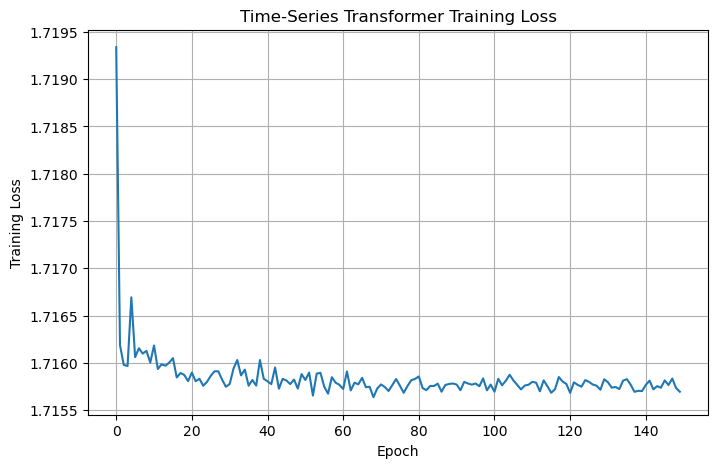

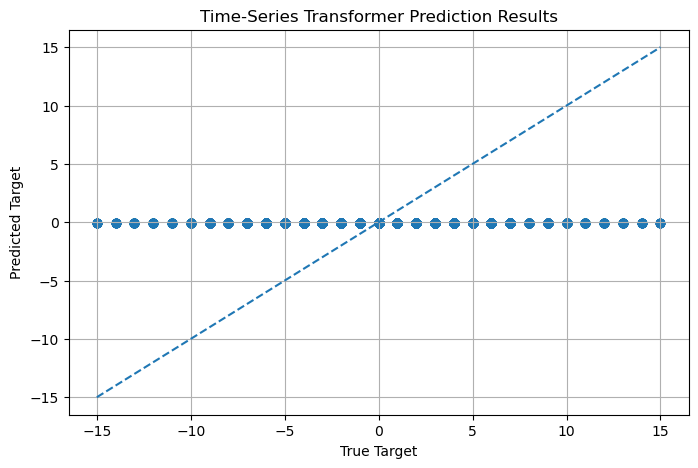

预测结果已保存： /home/wei/Data/light/03 Transformer/改进后/transformer_prediction_results.csv


In [32]:


# ============================================================
# 11. 训练
# ============================================================

train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        preds = model(batch_X)
        # loss = criterion(preds, batch_y)
        loss = weighted_smooth_l1_loss(preds, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss = epoch_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss:.6f}")



In [ ]:

# ============================================================
# 12. 测试集预测
# ============================================================

model.eval()

all_preds_scaled = []
all_targets_scaled = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        preds = model(batch_X)

        all_preds_scaled.extend(preds.cpu().numpy())
        all_targets_scaled.extend(batch_y.numpy())

y_pred_scaled = np.array(all_preds_scaled)
y_test_scaled_eval = np.array(all_targets_scaled)

# 反标准化回原始 target 尺度
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
y_test_original = scaler_y.inverse_transform(y_test_scaled_eval.reshape(-1, 1)).reshape(-1)


In [ ]:


# ============================================================
# 13. 评估
# ============================================================

mse = mean_squared_error(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)

print(f"\n测试集上的均方误差（MSE）：{mse}")
print(f"测试集上的平均绝对误差（MAE）：{mae}")

threshold = 2.0
errors = np.abs(y_pred - y_test_original)
correct_predictions = errors <= threshold

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")

extreme_samples = np.abs(y_test_original) > 10

if extreme_samples.sum() > 0:
    extreme_mse = mean_squared_error(
        y_test_original[extreme_samples],
        y_pred[extreme_samples]
    )

    print(f"极端值样本数量：{extreme_samples.sum()}")
    print(f"极端值样本的 MSE：{extreme_mse}")
else:
    print("测试集中没有满足条件的极端值样本，跳过极端值 MSE 计算。")



In [36]:
print("真实值统计：")
print("y_test min:", y_test_original.min())
print("y_test max:", y_test_original.max())
print("y_test mean:", y_test_original.mean())
print("y_test std:", y_test_original.std())

print("\n预测值统计：")
print("y_pred min:", y_pred.min())
print("y_pred max:", y_pred.max())
print("y_pred mean:", y_pred.mean())
print("y_pred std:", y_pred.std())

真实值统计：
y_test min: -15.0
y_test max: 15.0
y_test mean: 0.07188334
y_test std: 5.631653

预测值统计：
y_pred min: -0.05399522
y_pred max: -0.053993247
y_pred mean: -0.05399419
y_pred std: 2.5598726e-07


In [ ]:

# ============================================================
# 14. 可视化训练损失
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Time-Series Transformer Training Loss")
plt.grid(True)
plt.show()


# ============================================================
# 15. 可视化预测结果
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(y_test_original, y_pred, alpha=0.6)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("Time-Series Transformer Prediction Results")

min_value = min(y_test_original.min(), y_pred.min())
max_value = max(y_test_original.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid(True)
plt.show()


# ============================================================
# 16. 保存预测结果
# ============================================================

result_df = pd.DataFrame({
    "y_true": y_test_original,
    "y_pred": y_pred,
    "abs_error": np.abs(y_test_original - y_pred)
})

result_file = path / "transformer_prediction_results.csv"
result_df.to_csv(result_file, index=False)

print("预测结果已保存：", result_file)

In [33]:


# ============================================================
# 12. 测试集预测
# ============================================================

model.eval()

all_preds_scaled = []
all_targets_scaled = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        preds = model(batch_X)

        all_preds_scaled.extend(preds.cpu().numpy())
        all_targets_scaled.extend(batch_y.numpy())

y_pred_scaled = np.array(all_preds_scaled)
y_test_scaled_eval = np.array(all_targets_scaled)

# 反标准化回原始 target 尺度
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
y_test_original = scaler_y.inverse_transform(y_test_scaled_eval.reshape(-1, 1)).reshape(-1)



In [34]:

# ============================================================
# 13. 评估
# ============================================================

mse = mean_squared_error(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)

print(f"\n测试集上的均方误差（MSE）：{mse}")
print(f"测试集上的平均绝对误差（MAE）：{mae}")

threshold = 2.0
errors = np.abs(y_pred - y_test_original)
correct_predictions = errors <= threshold

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")

extreme_samples = np.abs(y_test_original) > 10

if extreme_samples.sum() > 0:
    extreme_mse = mean_squared_error(
        y_test_original[extreme_samples],
        y_pred[extreme_samples]
    )

    print(f"极端值样本数量：{extreme_samples.sum()}")
    print(f"极端值样本的 MSE：{extreme_mse}")
else:
    print("测试集中没有满足条件的极端值样本，跳过极端值 MSE 计算。")




测试集上的均方误差（MSE）：31.731361389160156
测试集上的平均绝对误差（MAE）：4.263829708099365

误差在 2.0 范围内的准确率：33.70%
极端值样本数量：340
极端值样本的 MSE：157.46426391601562


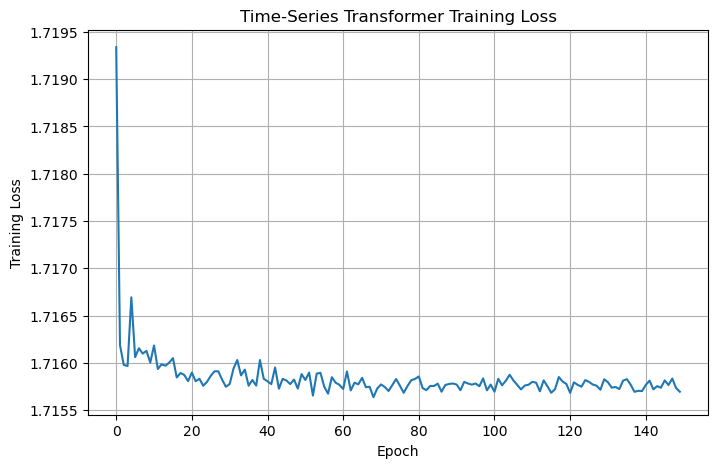

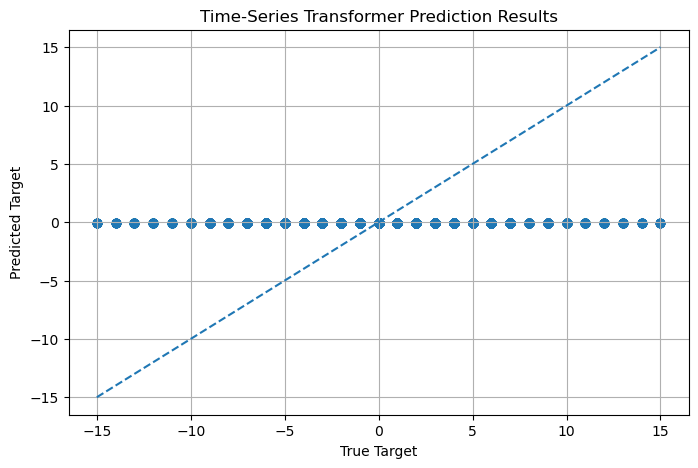

预测结果已保存： /home/wei/Data/light/03 Transformer/改进后/transformer_prediction_results.csv


In [35]:

# ============================================================
# 14. 可视化训练损失
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Time-Series Transformer Training Loss")
plt.grid(True)
plt.show()


# ============================================================
# 15. 可视化预测结果
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(y_test_original, y_pred, alpha=0.6)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("Time-Series Transformer Prediction Results")

min_value = min(y_test_original.min(), y_pred.min())
max_value = max(y_test_original.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid(True)
plt.show()


# ============================================================
# 16. 保存预测结果
# ============================================================

result_df = pd.DataFrame({
    "y_true": y_test_original,
    "y_pred": y_pred,
    "abs_error": np.abs(y_test_original - y_pred)
})

result_file = path / "transformer_prediction_results.csv"
result_df.to_csv(result_file, index=False)

print("预测结果已保存：", result_file)